# Taller Análisis Exploratorio de Datos

## Paso 1: Carga de datos

Abra el archivo en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargar el archivo dado, que contiene un dataset cuya información puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

Responda las siguientes preguntas:

- ¿Cuántas filas y columnas tiene el dataframe?

R/ El dataframe tiene 7043 filas (excluyendo la primera fila que corresponde al nombre de cada columna) y tiene 33 columnas.

- ¿De qué tipo de dato es cada columna?

R/ Hay columnas tipo objeto, entero y flotante. 

- ¿Las variables están en el tipo de dato correcto para su contenido?

R/ En general, las columnas tienen un tipo de dato que les corresponde pero hay algunas que deben corregirsen para que los cálculos que posteriormente se realicen sean correctos. Por ejemplo: 

- Total Charges es de tipo object y esto paso porque tiene registros en faltantes (las celdas se encuentran vacías), esto no permite que python la reconozca como numérica, entonces deberá convertirse a float y las celdas vacías deben convertirsen a NaN (nulos).

- Senior Citizen tiene datos solo de "No/Si" esta columna se puede reemplazar por tipo booleano o entero, reemplazando a "No" por "0" y "Si" por "1" y esto puede hacer que nuestro modelo funcione mejor.


In [1]:
from pathlib import Path
import pandas as pd

ROOT_DIR = Path().resolve().parent
DATA_DIR = ROOT_DIR / "data/raw"
file_path = 'Telco_customer_churn.csv'

df = pd.read_csv(DATA_DIR / file_path)
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

## Paso 2: Exploración inicial de los datos

Responda las siguientes preguntas:

- ¿Hay valores fuera de rango o imposibles, según el dominio del problema?

R/ No hay valores fuera del rango porque la desvación estandar es 0 y el mínimo y máximo son iguales.

- ¿Hay variables que no varían?

R/ Las variables que no varían las cuales se puede considerar a eliminarsen, ya que no ayudan a tomar una decisión diferente de la persona son:

Count siempre es 1.

Country siempre es United States.

State siempre es California. 

- Qué variables *cualitativas* tienen muchos valores únicos (alta cardinalidad)?

City: 1,129 valores únicos.

Zip Code: 1,652 valores únicos.

Lat Long / Latitude / Longitude: Al ser coordenadas geográficas, cada una tiene una cardinalidad muy alta.

Churn Reason: 20 motivos diferentes. Aunque no es tan alta como las anteriores, puede ser compleja para modelos simples.

- ¿Hay claves primarias o identificadores únicos?

CustomerID: Es la clave primaria. Cada registro tiene un ID alfanumérico único.

In [3]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [4]:
df.describe(include='object')

,CustomerID,Country,State,City,Lat Long,Gender,Senior Citizen,Partner,Dependents,Phone Service,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Total Charges,Churn Label,Churn Reason
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043,7043,1869
unique,7043,1,1,1129,1652,2,2,2,2,2,...,3,3,3,3,3,2,4,6531,2,20
top,3668-QPYBK,United States,California,Los Angeles,"34.159534, -116.425984",Male,No,No,No,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,,No,Attitude of support person
freq,1,7043,7043,305,5,3555,5901,3641,5416,6361,...,3095,3473,2810,2785,3875,4171,2365,11,5174,192


## Paso 3: Identificación de datos duplicados, datos nulos y problemas de formateo

Descarte las variables que solo toman un valor y las que son clave primaria. También descarte las variables **City** y **Lat Long**.

Responda las siguientes preguntas:

- ¿Qué variables tienen valores nulos? ¿En qué proporción?

R/
Churn Reason: Es la variable con más nulos, en proporción de 73.463013%.

Total Charges: Aunque técnicamente no aparece como NaN al cargar el archivo, tiene 11 valores en blanco (strings vacíos). En proporción es 0.15% aproximadamente.

- ¿Hay registros duplicados?

R/ No hay registros duplicados, ya que cada registro tiene un ID único.

- ¿Hay variables con problemas de formateo (fechas, monedas, mayúsculas/minúsculas)?

R/
Total Charges: Como mencione anteriormente, esta columna debería ser numérica pero viene como texto. 

Variables como Online Security o Tech Support a veces incluyen el valor "No internet service" en lugar de un simple "No". Esto se podría simplificar a una estructura booleana "Sí/No".


In [8]:
df.isnull().sum().sort_values(ascending=False)*100/df.shape[0]

Churn Reason         73.463013
CustomerID            0.000000
Count                 0.000000
State                 0.000000
Country               0.000000
Zip Code              0.000000
Lat Long              0.000000
Latitude              0.000000
City                  0.000000
Gender                0.000000
Senior Citizen        0.000000
Partner               0.000000
Dependents            0.000000
Tenure Months         0.000000
Phone Service         0.000000
Multiple Lines        0.000000
Longitude             0.000000
Internet Service      0.000000
Online Security       0.000000
Device Protection     0.000000
Online Backup         0.000000
Streaming TV          0.000000
Streaming Movies      0.000000
Contract              0.000000
Tech Support          0.000000
Paperless Billing     0.000000
Payment Method        0.000000
Total Charges         0.000000
Monthly Charges       0.000000
Churn Label           0.000000
Churn Value           0.000000
Churn Score           0.000000
CLTV    

In [15]:
#Variables descartadas

df.drop(['Count', 'Country', 'State', 'CustomerID', 'City', 'Lat Long'], axis=1).head()

,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,90003,33.964131,-118.272783,Male,No,No,No,2,Yes,No,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,90005,34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,90006,34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,90015,34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## Paso 4: Análisis de variables cuantitativas

Haga análisis de normalidad de las variables cuantitativas. Indique cuáles variables cumplen con el supuesto de normalidad y cuáles no.

Haga un análisis gráfico de outliers, y como resultado de este indique que variables tienen datos atípicos.

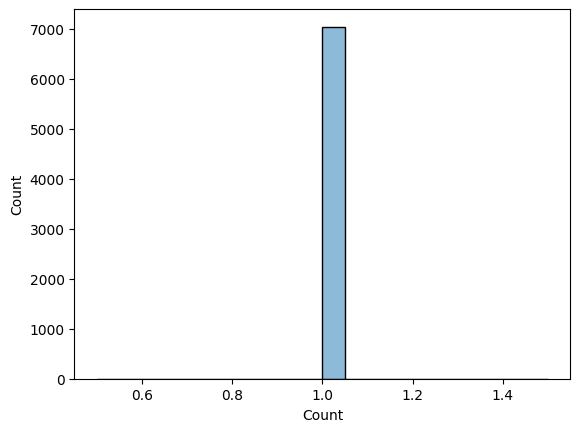

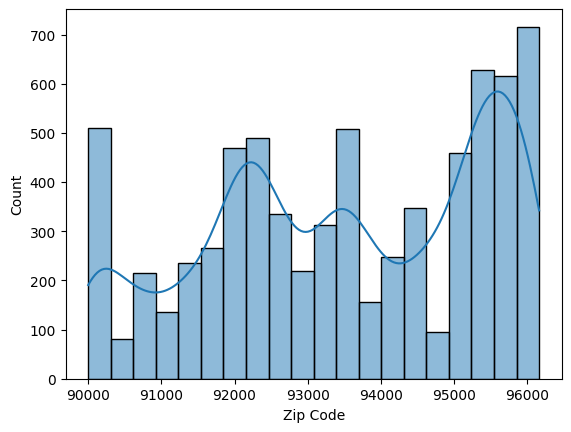

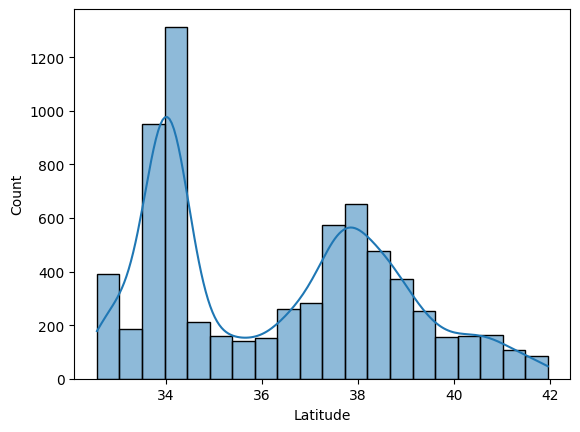

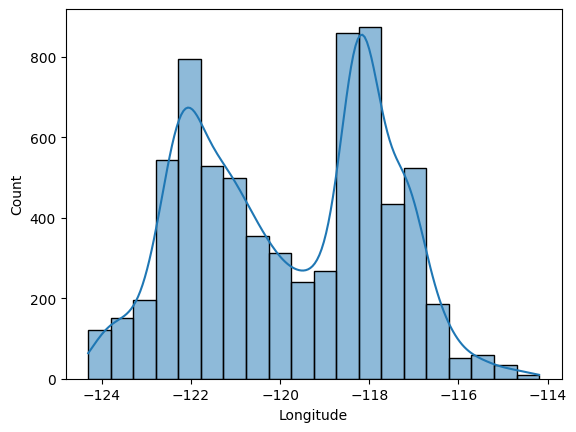

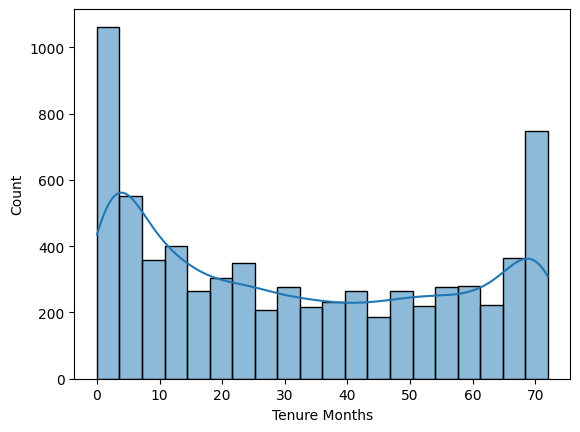

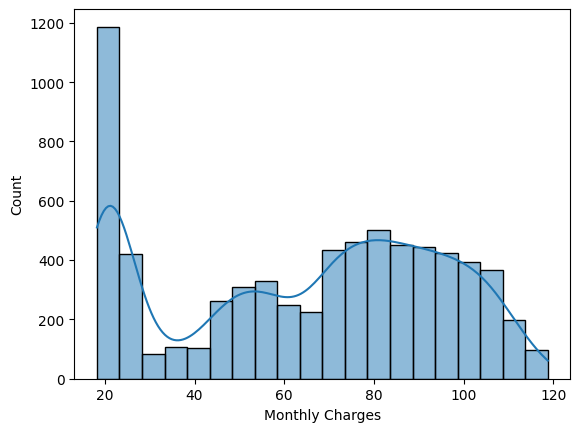

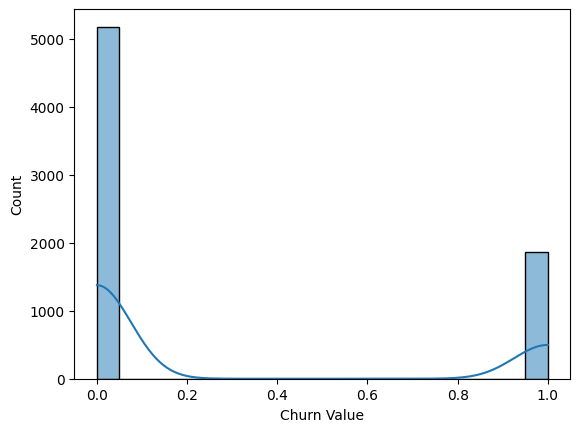

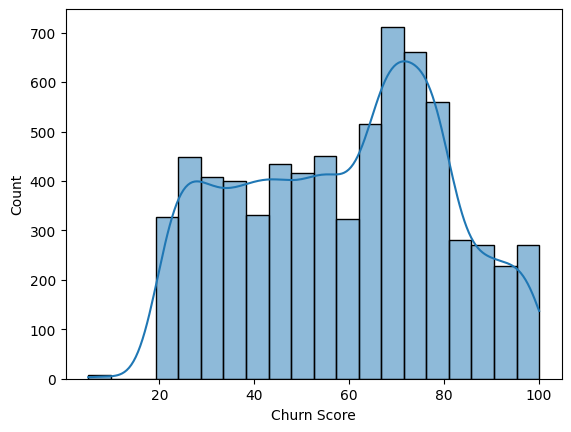

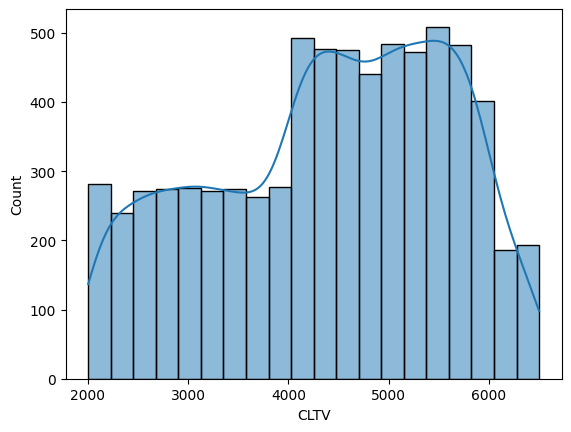

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in df.select_dtypes(include=['number']).columns:
    plt.figure()
    sns.histplot(data=df, x=col, bins=20, kde=True)
    plt.show()

In [17]:
for num in df.select_dtypes(include=['number']).columns:
    print(f"Asimetría de {num}: {df[num].skew():.3f} \n")

Asimetría de Count: 0.000 

Asimetría de Zip Code: -0.251 

Asimetría de Latitude: 0.304 

Asimetría de Longitude: -0.041 

Asimetría de Tenure Months: 0.240 

Asimetría de Monthly Charges: -0.221 

Asimetría de Churn Value: 1.063 

Asimetría de Churn Score: -0.090 

Asimetría de CLTV: -0.312 



In [18]:
for num in df.select_dtypes(include=['number']).columns:
    print(f"Kurtosis de {num}: {df[num].kurt():.3f} \n")

Kurtosis de Count: 0.000 

Kurtosis de Zip Code: -1.154 

Kurtosis de Latitude: -1.136 

Kurtosis de Longitude: -1.136 

Kurtosis de Tenure Months: -1.387 

Kurtosis de Monthly Charges: -1.257 

Kurtosis de Churn Value: -0.870 

Kurtosis de Churn Score: -1.006 

Kurtosis de CLTV: -0.934 



## Paso 5: Análisis de variables cualitativas

Responda a las siguientes preguntas:

- ¿Cómo se comportan las variables categóricas?
- ¿Existen variables de alta cardinalidad?
- ¿Existen categorías atípicas?

## Paso 6: Análisis bivariado.

Se va a suponer que con este archivo de datos se desea hacer un modelo de aprendizaje de máquina que prediga la **Churn Value**.


Mediante análisis de gráficas responda las siguientes preguntas:

- ¿Cómo se relaciona cada una de las variables cuantitativas con la variable que se desea predecir?
- ¿Cómo se relaciona cada una de las variables cualitativas con la variable que se desea predecir?
- De acuerdo con estos análisis, ¿cuáles variables parecerían ser buenas predictoras, y cuáles no?
